### Determining Market Volatility using XGBoost

In [44]:
# Let's make a XGBoost based script to determine fluctuation of markets based on daily asset historical data. 
# Personal challenges involve looking at biotech equities again or energy equities such as Plug Power or Exxon
# Other interesting questions are listed below. 

# To track time it takes to run sections of code 
import time 

# import libraries/packages
import numpy as np 
import pandas as pd 
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix 
import xgboost as xgb
from xgboost import XGBRegressor
import random as rand

In [45]:
# Download historical data from yfinance (this is the basic framework)
ticker_data = ['JPM','GS','BAC']
volatility_dates = range(1,6)

data = yf.download('SPY', start="2018-01-01", end="2026-01-01") # CAL ALSO DO s&p 500 ETF

# Conver to pandas dataframe
df = pd.DataFrame()
df['Close'] = data['Close'] # may consider anther way to do this 

# Calculate daily log returns
df['Log_Return'] = np.log(df["Close"] / df["Close"].shift(1))

# Define volatility as rolling standard deviation of past/future returns (e.g., 21 days)
df['Volatility'] = df['Log_Return'].rolling(window=21).std() * np.sqrt(252)

# Create lagged features for the model
for lag in volatility_dates:
  df[f"Lag_{lag}"] = df['Volatility'].shift(lag)

df = df.dropna()

[*********************100%***********************]  1 of 1 completed


In [46]:
# import additional packages
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Define features and target. Initialize rmse
feature_cols = [f"Lag_{lag}" for lag in volatility_dates]
X = df[feature_cols]
y = df['Volatility']

rmse_scores = []

# 80% train, 20% test (I can also split the training dataset - k-fold cross-validation)
split_idx = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train XGBoost Regressor
model = XGBRegressor(n_estimators=100, learning_rate=0.25, max_depth=3)
model.fit(X_train, y_train)

# Predict and calculate RMSE 
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
rmse_scores.append(rmse)
print(f"RMSE: {np.mean(rmse_scores):.4f}")

# Predict volatility
predictions = model.predict(X_test)

RMSE: 0.0168


In [47]:
# Approaching the same problem using time series split (an equivalent to k-fold given this is time dependent data)
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores_kfold = []

# 2. Loop through the k-partitions
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    # Partition the data chronologically
    X_train_k, X_test_k = X.iloc[train_idx], X.iloc[test_idx]
    y_train_k, y_test_k = y.iloc[train_idx], y.iloc[test_idx]

    # Initialize and train the model
    model_k = XGBRegressor(n_estimators=100, learning_rate=0.25, max_depth=3)
    model_k.fit(X_train_k, y_train_k)

    # Predict and calculate RMSE for this partition
    predictions_k = model_k.predict(X_test_k)
    rmse_kfold = np.sqrt(mean_squared_error(y_test_k, predictions_k))
    rmse_scores_kfold.append(rmse_kfold)

    print(f"Fold {fold + 1} RMSE: {rmse_kfold:.4f}")

# 3. Overall Performance
print(f"\nAverage Cross-Validation RMSE: {np.mean(rmse_scores_kfold):.4f}")

Fold 1 RMSE: 0.1539
Fold 2 RMSE: 0.0094
Fold 3 RMSE: 0.0163
Fold 4 RMSE: 0.0075
Fold 5 RMSE: 0.0180

Average Cross-Validation RMSE: 0.0410


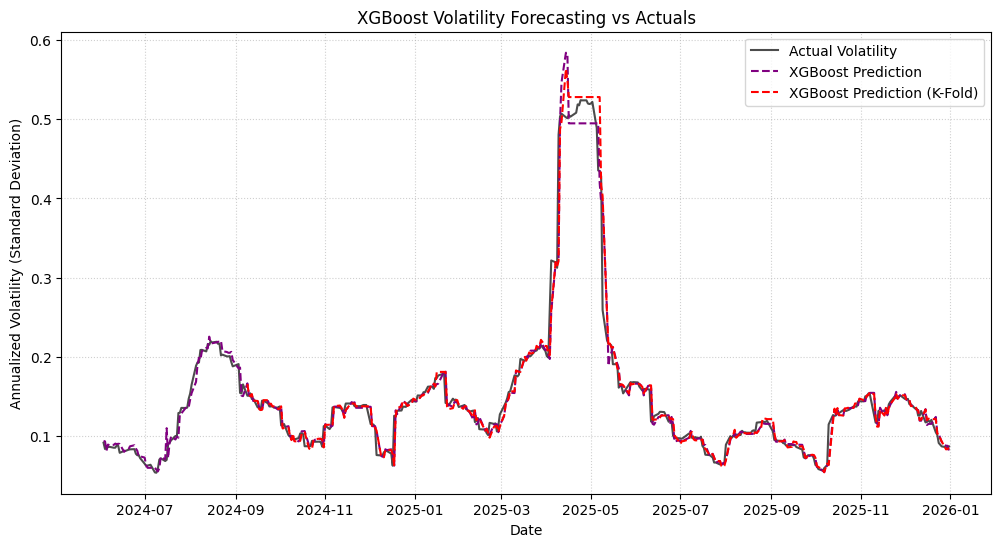

In [50]:
import matplotlib.pyplot as plt
# Align predictions back to datetime index for clean plotting
plot_df_k = pd.DataFrame(index=y_test_k.index)
plot_df = pd.DataFrame(index=y_test.index)

plot_df_k['Actual_Volatility'] = y_test_k.values
plot_df['Actual_Volatility'] = y_test.values

plot_df_k['Predicted_Volatility'] = predictions_k
plot_df['Predicted_Volatility'] = predictions

# Make chart
plt.figure(figsize=(12, 6))
plt.plot(
    plot_df.index,
    plot_df['Actual_Volatility'],
    label='Actual Volatility',
    color='black',
    alpha=0.7,
)
plt.plot(
    plot_df.index,
    plot_df['Predicted_Volatility'],
    label='XGBoost Prediction',
    color='purple',
    linestyle="--",
)
plt.plot(
    plot_df_k.index,
    plot_df_k['Predicted_Volatility'],
    label='XGBoost Prediction (K-Fold)',
    color='red',
    linestyle='--',
)

plt.title("XGBoost Volatility Forecasting vs Actuals")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility (Standard Deviation)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [53]:
# Forecast over five days
live_forecast_input = df[feature_cols].tail(1)
FORECAST_HORIZON = 5
df["Future_Volatility"] = df["Volatility"].shift(-FORECAST_HORIZON)

# Evalyate on the backtest set
test_predictions = model.predict(X_test)
test_predictions_k = model_k.predict(X_test_k)

# Generate the future forecast 
future_prediction = model.predict(live_forecast_input)[0]
future_prediction_k = model_k.predict(live_forecast_input)[0]

print(f"--- Volatility Forecast Results ---")
print(
    f"Current Volatility (Today): {df['Volatility'].dropna().iloc[-1]:.4f}"
)
print(
    f"Predicted Volatility ({FORECAST_HORIZON} Days From Now): {future_prediction:.4f}"
)
print(
    f"Predicted Volatility (K-Fold) ({FORECAST_HORIZON} Days From Now): {future_prediction_k:.4f}"
)


--- Volatility Forecast Results ---
Current Volatility (Today): 0.0873
Predicted Volatility (5 Days From Now): 0.0815
Predicted Volatility (K-Fold) (5 Days From Now): 0.0853
